### ✏️ Zadanie 5 – Porównanie Learning Rates

Dla f(x) = x² uruchom GD z różnymi learning rates.

**Wymagania:**
- Przetestuj: η = 0.001, 0.01, 0.1, 0.5, 1.0, 1.5
- Punkt startowy: x = 5
- 30 iteracji
- Określ, które η działa najlepiej

*(proste)*

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def gradient_descent(f, df, x, learning_rate, iterations):
    trajectory = [x]
    
    for _ in range(iterations):
        gradient = df(x)
        x -= learning_rate * gradient
        trajectory.append(x)
        
    return x, np.array(trajectory)

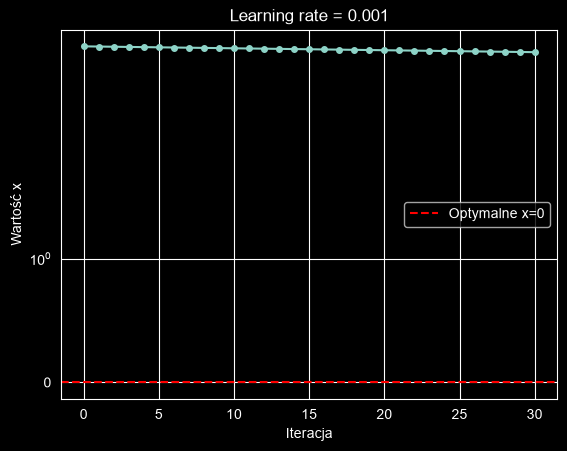

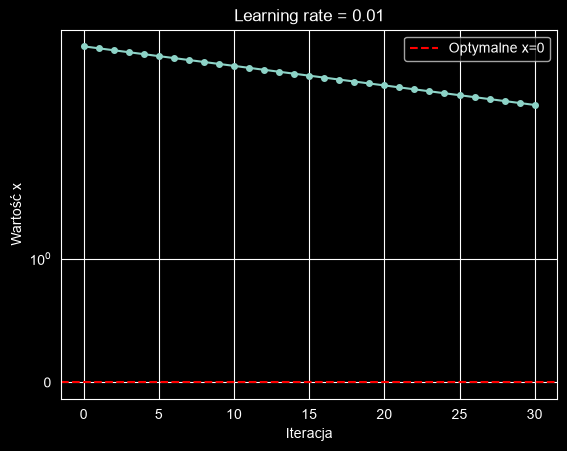

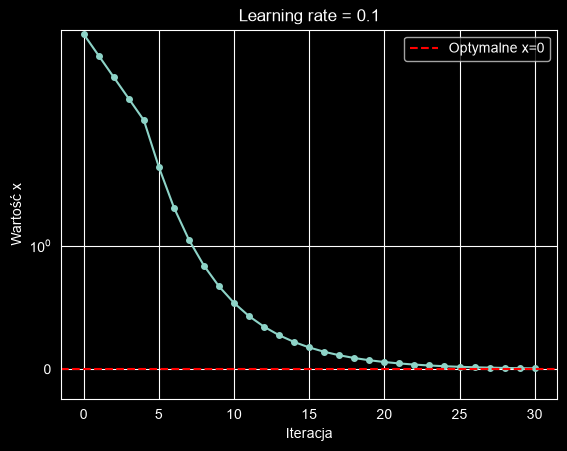

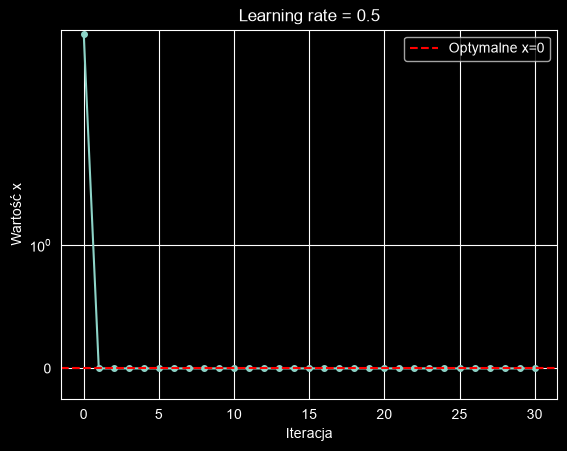

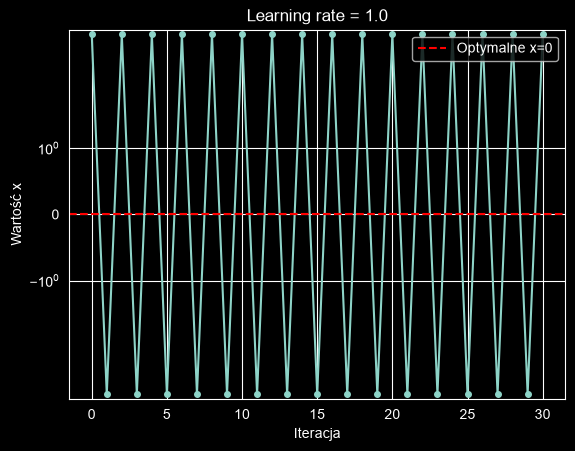

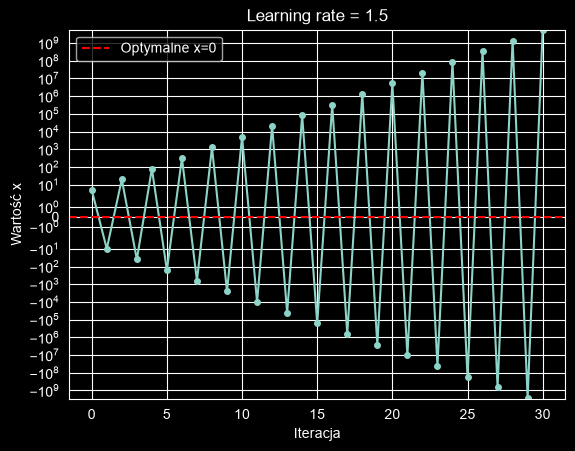

η = 0.001 → x_final =     4.708540 | 🔶 Bliski minimum
η = 0.010 → x_final =     2.727422 | 🔶 Bliski minimum
η = 0.100 → x_final =     0.006190 | ✅ Zbieżny
η = 0.500 → x_final =     0.000000 | ✅ Zbieżny
η = 1.000 → x_final =     5.000000 | 🔶 Bliski minimum
η = 1.500 → x_final = 5368709120.000000 | ⚠️ Niezbieżny


In [6]:
fx = lambda x: x ** 2
dfx = lambda x: 2 * x

learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5]
x_start = 5
iterations = 30

results = {}

for learning_rate in learning_rates:
    final_x, trajectory = gradient_descent(
        fx, dfx, x_start, learning_rate, iterations
    )
    results[learning_rate] = (final_x, trajectory)
    
    plt.figure()
    plt.plot(trajectory, marker='o', markersize=4)
    plt.axhline(y=0, color='r', linestyle='--', label='Optymalne x=0')
    plt.title(f'Learning rate = {learning_rate}')
    plt.xlabel('Iteracja')
    plt.ylabel('Wartość x')
    plt.legend()
    plt.grid(True)
    plt.yscale("symlog")
    plt.show()

for lr, (final_x, trajectory) in results.items():
    convergence = "✅ Zbieżny" if abs(final_x) < 0.1 else ("⚠️ Niezbieżny" if abs(final_x) > 10 else "🔶 Bliski minimum")
    print(f"η = {lr:5.3f} → x_final = {final_x:12.6f} | {convergence}")
    